I will be utilizing this space to import any documents and libraries that are necessary to this project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [71]:
#I'm loading in the energy data that will be used for this project
df_EN = pd.read_csv('../Data/ENB2012_data 2.csv')

In [68]:
#I used this code to check the summary of the data
df_EN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [93]:
#This specific dataset has 8 attributes which are denoted by X1 through X8 and two responses/outcomes 
# which are denoted by Y1 and Y2. To clean this, i used the function below to rename these attributes to become much clearer for interpretation
df_EN.rename(columns={'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load',
}, inplace=True)


In [82]:
#I used this function to inspect the first 5 rows of the Energy DataFrame
df_EN.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [83]:
#I used this function to inspect the last five rows of the energy DataFrame
df_EN.tail()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
763,0.64,784.0,343.0,220.5,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.5,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.5,3.5,4,0.4,5,16.48,16.61
767,0.62,808.5,367.5,220.5,3.5,5,0.4,5,16.64,16.03


In [84]:
#I used this function to generate a summary table for the numeri columns of the Energy DataFrame. 
#It is for the purpose of understanding the distribtuion and characteristics of my data
df_EN.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [85]:
def count_column(df,col_list):
    count= {}
    for elem in col_list:
        count[elem] = df[elem].value_counts()
    return count

In [86]:
#This function helps me to see the dimension of the DataFrame
#  including number of rows and colums so 10 rows and 768 columns
df_EN.shape

(768, 10)

In [87]:
#I need to know if there are any missing values in my dataset so i run this code
#I can clearly see that this dataset has no missing values
df_EN.isna().sum()

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

Text(0.5, 1.0, 'Histogram of Heating Load')

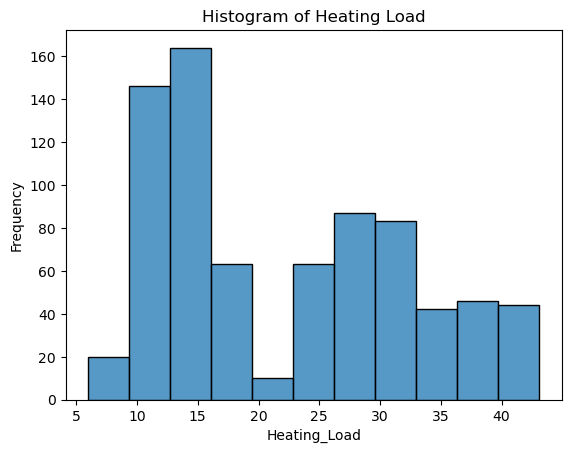

In [104]:
#I will be assessing heating load and cooling load as a function of the 8 parameters we have set forth
#My target variables will be heating load and cooling load
#The histogram below shows the distribution of Heating Load Values
sns.histplot(df_EN['Heating_Load'])
plt.ylabel("Frequency")
plt.title("Histogram of Heating Load")

Text(0.5, 1.0, 'Histogram of Cooling Load')

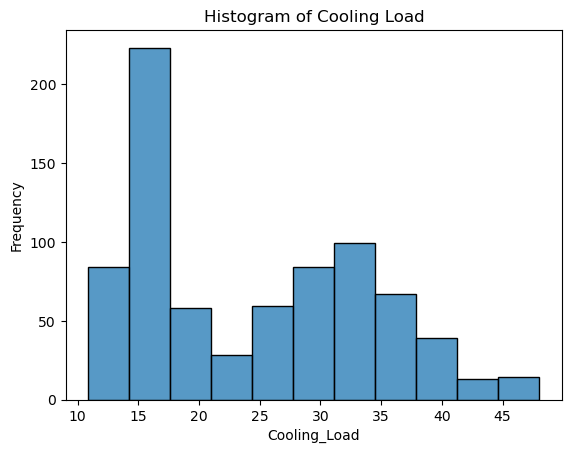

In [103]:
sns.histplot(df_EN['Cooling_Load'])
plt.ylabel("Frequency")
plt.title("Histogram of Cooling Load")

In [105]:
x=['Wall_Area', 'Roof_Area']  
#input features
y=['Heating_Load','Cooling_Load'] 
#target variables

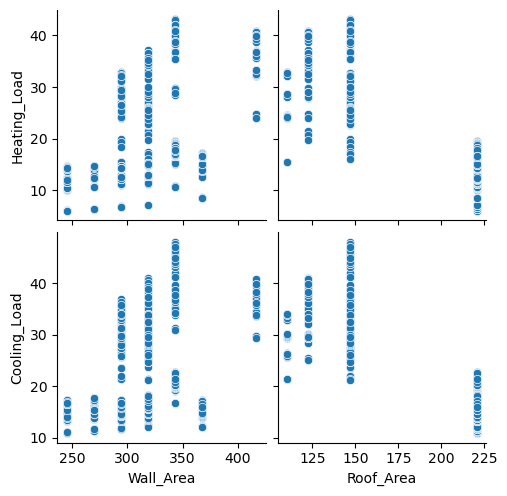

In [90]:
#I will utilize the Pairplot to see how the 8 features influence energy demand
sns.pairplot(df_EN, x_vars=x, y_vars=y)


In [63]:
corr=df_EN.corr()
print(corr)

                           Relative_Compactness  Surface_Area     Wall_Area  \
Relative_Compactness               1.000000e+00 -9.919015e-01 -2.037817e-01   
Surface_Area                      -9.919015e-01  1.000000e+00  1.955016e-01   
Wall_Area                         -2.037817e-01  1.955016e-01  1.000000e+00   
Roof_Area                         -8.688234e-01  8.807195e-01 -2.923165e-01   
Overall_Height                     8.277473e-01 -8.581477e-01  2.809757e-01   
Orientation                        5.878473e-17 -3.066832e-17 -2.510469e-17   
Glazing_Area                      -2.096261e-15  3.623317e-15 -8.647953e-17   
Glazing_Area_Distribution         -1.896390e-16  2.441409e-15  2.077332e-16   
Heating_Load                       6.222722e-01 -6.581202e-01  4.556712e-01   
Cooling_Load                       6.343391e-01 -6.729989e-01  4.271170e-01   

                              Roof_Area  Overall_Height   Orientation  \
Relative_Compactness      -8.688234e-01    8.277473e-01  

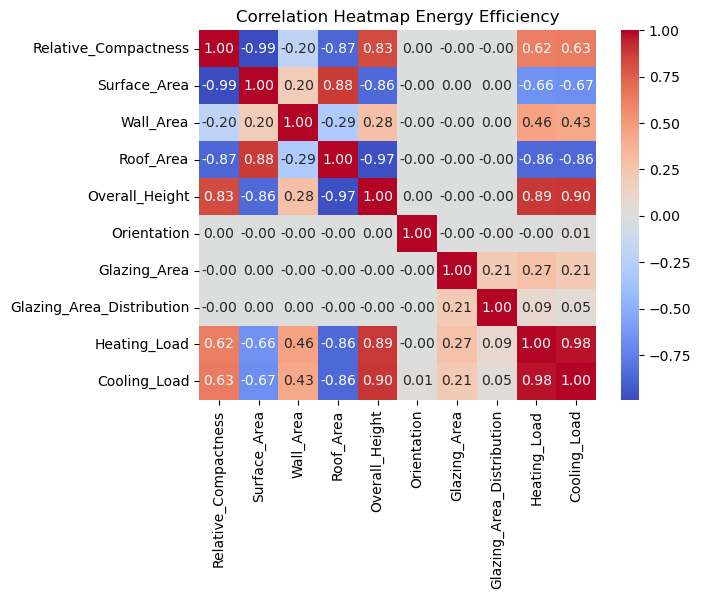

In [ ]:
#anything more than .7 you may have to drop depending on how relevant it is to my objective
#Analyzing this heatmap, I check for multicollinearity. I observe that surface area and wall area will be dropped from the feature set to reduce redundancy and improve stability.
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap Energy Efficiency")
plt.show()